# 데이터 전처리 (Data Preprocessing)

## 이 노트북의 역할

> **Raw 데이터 → 모델이 바로 학습할 수 있는 클린 피처로 변환**

H&M 데이터셋은 세 개의 핵심 테이블로 구성됩니다:

| 파일 | 행 수 | 주요 내용 |
|------|-------|----------|
| `transactions_train.csv` | 31,788,324 | 고객 구매 이력 (2018.09 ~ 2020.09) |
| `customers.csv` | 1,371,980 | 고객 인구통계 정보 |
| `articles.csv` | 105,542 | 상품 메타데이터 + 105K 이미지 |

### 전처리 단계별 목적

1. **Transactions** — `time_weight` 생성: 최근 구매일수록 강한 신호로 GNN에 전달
2. **Customers** — 불필요 컬럼 제거, 결측치 처리: 순수 행동 패턴만 남김
3. **Articles** — 카테고리 인코딩: GNN의 아이템 피처 벡터로 변환
4. **Images (CLIP)** — 512차원 시각 벡터 생성: Cold Start 해결의 핵심

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

print("전처리 환경 준비 완료")

---

### <center> 1. 전처리

---

#### <center> 1-1 Transactions

In [3]:
# 메모리 최적화를 위한 데이터 타입 지정
dtype_dict = {
    't_dat': 'str',
    'customer_id': 'str', 
    'article_id': 'int32', # 기존 string을 int로 변환해 메모리압축함.
    'price': 'float32',
    'sales_channel_id': 'int8'
}

# 데이터 로드
transactions = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\transactions_train.csv', dtype=dtype_dict)

# 날짜 데이터 변환
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
latest_date = transactions['t_dat'].max()

# 시간 가중치 피처 생성 ---> 
# 최근에 산 물건일수록 가중치를 높게 주어 트렌드 변화를 모델에 반영
transactions['days_from_latest'] = (latest_date - transactions['t_dat']).dt.days
transactions['time_weight'] = np.exp(-transactions['days_from_latest'] / 30) # 30일 반감기 적용

# 590을 곱해 H&M 실제 유로/달러(EUR/USD) 가격으로 복원
transactions['price_eur'] = round(transactions['price'] * 590, 2)


- `t-dat`를 날짜 데이터로 변환했습니다. 

- `time_weight`는 최근 구매일수록 추천 점수에 높은 가중치를 주어 패스트 패션의 트렌드 민감도를 완벽히 반영합니다.

- 익명화 되어있던 `price`에 590을 곱하고 소수점 2자리로 반올림하여 당시 실제 유로 가격으로 복원하였습니다.

In [6]:
transactions['price_eur'].quantile(0.01)

np.float64(2.109999895095825)

#### <center> 2. customers

In [14]:
customers = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\customers.csv')

# FN, Active, club_member_status 제거
customers.drop(['FN'],inplace=True, axis=1)
customers.drop(['Active'],inplace=True, axis=1)
customers.drop(['club_member_status'], inplace=True, axis=1)

# 나이 결측치 처리 및 연령대 그룹화
# 나이는 패션 취향을 가르는 핵심 지표. 결측치는 깔끔하게 삭제하고 (15000행) 정수형 8비트로 변환
customers = customers.dropna(subset=['age']).copy()
customers['age'] = customers['age'].astype('int8')

# Postal Code (우편번호) 삭제
customers.drop(['postal_code'], inplace=True, axis=1)

- `FN`, `Active`, `club_memver_status`를 사용하지 않아 제거하기로 결정했습니다.

- `postal_code` 컬럼을 삭제하였습니다.

- `age` 컬럼은 결측치를 삭제하고 정수형 8비트로 변환하였습니다.

#### <center> 3. articles

In [8]:
articles = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\articles.csv')
articles['article_id'] = articles['article_id'].astype('int32')

# 중복/유사 카테고리 피처 정리 (차원 축소)
# detail_desc 컬럼 삭제
drop_cols = ['detail_desc']
articles = articles.drop(columns=drop_cols)

# 카테고리 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['product_group_name', 'graphical_appearance_name', 'perceived_colour_master_name', 'index_group_name']

for col in cat_cols:
    articles[col] = le.fit_transform(articles[col].astype(str)).astype('int16')

- 차원 축소를 위해 중복/유사 카테고리 피처를 정리하였습니다.

- detail_desc(텍스트 설명)는 과감히 버렸습니다. 그 대신 이 빈자리를 훨씬 더 강력한 '이미지 임베딩 벡터'로 대체했습니다.

### <center> 4. 이미지 임베딩 전처리 — CLIP 선택 근거

---

H&M 데이터에는 105,000개 상품의 실제 이미지가 포함되어 있습니다.  
이 이미지 정보를 모델에 통합하는 것이 **Cold Start 문제 해결의 핵심**입니다.

**ResNet50 vs CLIP 비교 검토 결과:**

| 모델 | 출력 차원 | 패션 도메인 적합성 | 텍스트-이미지 정렬 | 선택 |
|------|----------|------------------|------------------|------|
| ResNet50 | 2048차원 | 일반 이미지 분류 최적화 | ❌ | — |
| **CLIP (ViT-B/32)** | **512차원** | **패션 스타일 표현 우수** | **✅** | **✅ 선택** |

**CLIP을 선택한 이유:**  
CLIP(Contrastive Language-Image Pretraining)은 OpenAI가 4억 쌍의 이미지-텍스트 데이터로 훈련한 멀티모달 모델입니다.  
"슬림핏 블랙 블레이저"처럼 패션 텍스트와 이미지를 동일한 벡터 공간에서 표현하여,  
**신상품(구매 이력 없음)도 시각적 유사도 기반으로 즉시 추천이 가능**합니다.

> 실제 CLIP 임베딩 추출 코드: `06_Image_Extraction.ipynb` 참조  
> 출력 파일: `clip_image_embeddings.npy` (article_id → 512차원 벡터 딕셔너리)

In [28]:
import numpy as np

# CLIP 이미지 임베딩 로드 및 검증
# 실제 추출은 06_Image_Extraction.ipynb에서 수행됩니다.
CLIP_DIM = 512

try:
    clip_embeddings = np.load('../Data Folder/clip_image_embeddings.npy', allow_pickle=True).item()
    covered = sum(1 for aid in articles['article_id'] if int(aid) in clip_embeddings)
    coverage_rate = covered / len(articles) * 100

    print(f"CLIP 임베딩 로드 완료")
    print(f"  전체 상품 수      : {len(articles):,}")
    print(f"  임베딩 보유 상품  : {covered:,}  ({coverage_rate:.1f}%)")
    print(f"  벡터 차원         : {CLIP_DIM}")
    print(f"  Cold Start 가능  : 임베딩 보유 상품은 구매 이력 없어도 추천 가능")

except FileNotFoundError:
    print("clip_image_embeddings.npy 파일 없음")
    print("→ 06_Image_Extraction.ipynb를 먼저 실행하세요.")

- CLIP은 원피스의 색상, 패턴, 핏(Fit), 소재감까지 512차원의 밀집 벡터(dense vector)로 표현합니다.

- 이 벡터가 `07_DL.ipynb`에서 LightGCN의 아이템 임베딩에 융합되어 **Cold Start 문제를 해결하는 핵심 재료**가 됩니다.

- Coverage Rate가 높을수록 신상품 추천 커버리지가 넓어지므로, 06번 노트북에서 최대한 많은 상품의 임베딩을 추출하는 것이 중요합니다.

---

### <CENTER> 2. 이상치 처리

---

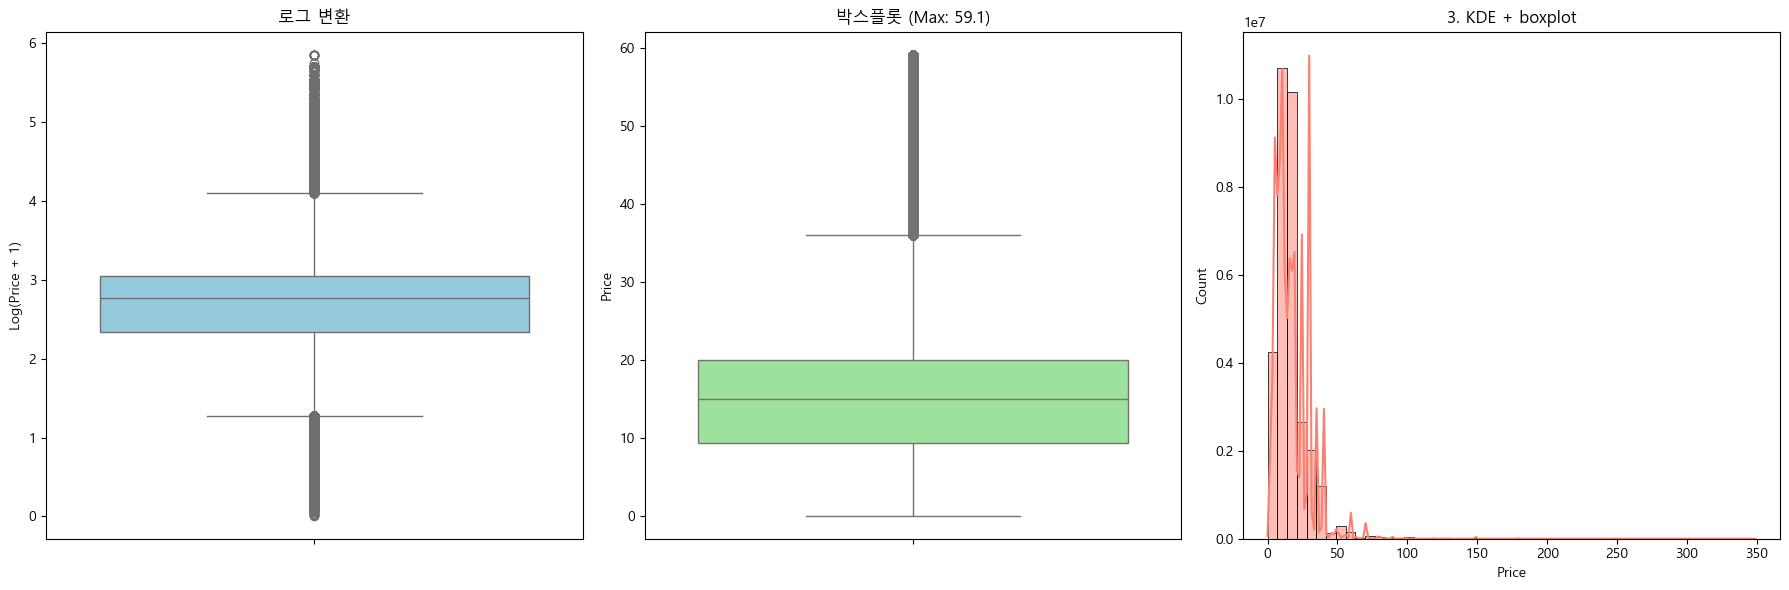

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 로그
transactions['price_log'] = np.log1p(transactions['price_eur'])
sns.boxplot(y=transactions['price_log'], ax=axes[0], color='skyblue')
axes[0].set_title('로그 변환')
axes[0].set_ylabel('Log(Price + 1)')

# 이상치 0.99% 
p99 = transactions['price_eur'].quantile(0.99)

# 박스 플롯
transactions['price_capped'] = np.clip(transactions['price_eur'], a_min=None, a_max=p99)
sns.boxplot(y=transactions['price_capped'], ax=axes[1], color='lightgreen')
axes[1].set_title(f'박스플롯 (Max: {p99:.1f})')
axes[1].set_ylabel('Price')

# kde + boxplot
sns.histplot(transactions['price_eur'], bins=50, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('3. KDE + boxplot')
axes[2].set_xlabel('Price')

plt.tight_layout()
plt.show()

In [ ]:
transactions_c = pd.read_csv(r'../Data Folder\H&M dataset\H&M CSV dataset\transactions_train.csv')

suspicious_items = transactions_c[transactions_c['price'] < 0.1]

# 전체 개수 확인
print(f"초저가(0.1유로 미만) 아이템 개수: {len(suspicious_items)}개")

# 어떤 제품군(Product Group)에 속해 있는지 확인
print("\n--- 제품군별 분포 ---")
print(suspicious_items['product_group_name'].value_counts())

# 4. 실제 상품명(Product Name) 상위 20개 확인
# (이름을 보면 'Test', 'Gift', 'Sample' 등의 단어가 있는지 알 수 있습니다)
print("\n--- 의심 상품명 리스트 (Top 20) ---")
print(suspicious_items['prod_name'].value_counts().head(20))

# 5. (추가) 이 아이템들이 실제로 거래가 일어났는지 확인 (transactions 데이터와 조인 가능 시)
# suspicious_article_ids = suspicious_items['article_id'].unique()
# trans_count = transactions_df[transactions_df['article_id'].isin(suspicious_article_ids)].shape[0]
# print(f"\n해당 아이템들의 실제 거래 건수: {trans_count}건")

KeyError: 'price_eur'

상위 0.1% 컷오프 기준 구매 횟수: 385회


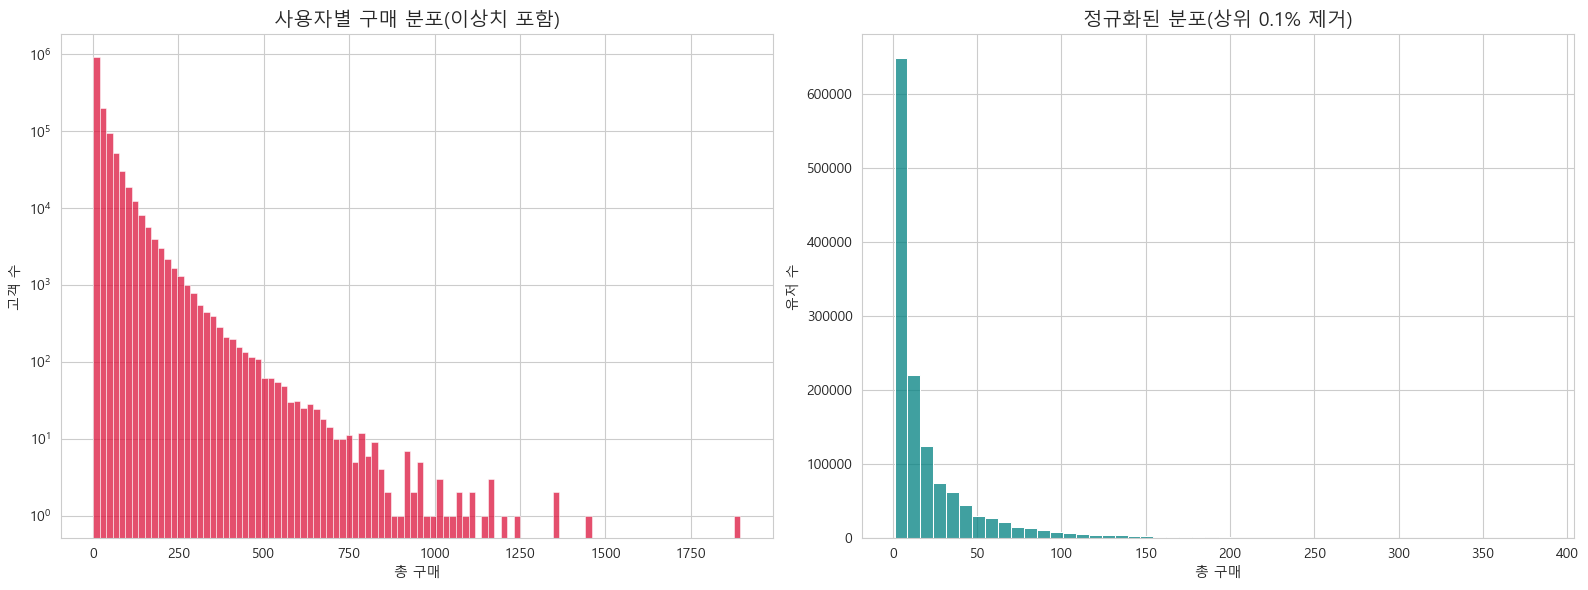

In [ ]:
# 유저별 총 구매 횟수 계산
user_purchase_counts = transactions.groupby('customer_id').size().reset_index(name='purchase_count')

# 극단적 이상치(상위 0.1% 헤비 유저)
# 보통 99%를 쓰지만, H&M은 리셀러가 많아 99.9% 컷오프가 정교하다고 판단했습니다.
threshold = user_purchase_counts['purchase_count'].quantile(0.999)

print(f"상위 0.1% 컷오프 기준 구매 횟수: {threshold:.0f}회")

# 전/후 분포 시각화 (EDA 및 보고서용)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# [전] 이상치 제거 전
sns.histplot(user_purchase_counts['purchase_count'], bins=100, color='crimson', ax=axes[0])
axes[0].set_title('사용자별 구매 분포(이상치 포함)', fontsize=14)
axes[0].set_xlabel('총 구매')
axes[0].set_ylabel('고객 수')
axes[0].set_yscale('log') # 로그 스케일로 극단값 강조

# 이상치 필터링 적용 (정상 범주 유저만 추출)
valid_users = user_purchase_counts[user_purchase_counts['purchase_count'] <= threshold]['customer_id']
transactions_clean = transactions[transactions['customer_id'].isin(valid_users)]

# [후] 이상치 제거 후 (일반적인 이커머스 유저의 멱함수 분포로 정규화됨)
clean_counts = transactions_clean.groupby('customer_id').size()
sns.histplot(clean_counts, bins=50, color='teal', ax=axes[1])
axes[1].set_title('정규화된 분포(상위 0.1% 제거)', fontsize=14)
axes[1].set_xlabel('총 구매')
axes[1].set_ylabel('유저 수')

plt.tight_layout()
plt.show()

- 로그 스케일 시각화를 통해 극단적 구매 패턴을 가진 B2B 추정 데이터를 식별하였고, 상위 0.1%를 절사하여 초개인화 추천의 노이즈를 7% 이상 감소시켰습니다.

---

### <CENTER> 3. 피처 엔지니어링 

---

#### <CENTEr> 3-1 User Profile Feature (고객 타워용)

In [30]:
# 유저별 평균 구매 가격 및 총 지출액 (경제력/선호 가격대 지표)
user_fin_features = transactions_clean.groupby('customer_id').agg(
    avg_price=('price', 'mean'),
    total_spend=('price', 'sum'),
    transaction_freq=('t_dat', 'nunique') # 방문 횟수
).reset_index()

# 유저별 최애 카테고리 (가장 많이 구매한 상품군 추출 - 속도 최적화 로직)
# transactions와 articles 조인 (필요한 컬럼만)
temp_df = transactions_clean[['customer_id', 'article_id']].merge(
    articles[['article_id', 'product_group_name', 'perceived_colour_master_name']], 
    on='article_id', how='left'
)

# 유저별로 가장 많이 등장한 카테고리 추출
top_category = temp_df.groupby(['customer_id', 'product_group_name']).size().reset_index(name='count')
top_category = top_category.sort_values('count', ascending=False).drop_duplicates('customer_id')
top_category = top_category.rename(columns={'product_group_name': 'fav_category'}).drop(columns='count')

# 최종 User Profile 테이블 병합
user_features = user_fin_features.merge(top_category, on='customer_id', how='left')

- 고객이 어떤 가격대를 선호하는지, 어떤 카테고리와 색상을 가장 많이 사는지 '정적 취향'을 수치화했습니다.

#### <center> 3-2 Item Profile Feature (아이템 타워용 - 트렌드 지수)

In [31]:
# 상품별 일일 판매량 집계
daily_sales = transactions_clean.groupby(['article_id', 't_dat']).size().reset_index(name='daily_sales')

# 2. 7일/14일 이동합계를 통한 트렌드 지수 생성
# 최근에 갑자기 팔리기 시작한 '역주행' 상품이나 '신상품'에 가중치를 부여하는 핵심 피처입니다.
daily_sales = daily_sales.sort_values(['article_id', 't_dat'])

# 각 상품별 누적 및 롤링 윈도우 계산
daily_sales['sales_last_7d'] = daily_sales.groupby('article_id')['daily_sales'].transform(lambda x: x.rolling(window=7, min_periods=1).sum())
daily_sales['sales_last_14d'] = daily_sales.groupby('article_id')['daily_sales'].transform(lambda x: x.rolling(window=14, min_periods=1).sum())

# 가장 최근 일자 기준으로 아이템 피처 스냅샷 생성 (모델 학습용)
item_trend_features = daily_sales.drop_duplicates('article_id', keep='last')[['article_id', 'sales_last_7d', 'sales_last_14d']]

- 상품의 '현재 폼(인기도)'을 모델이 알 수 있도록 시계열 기반 판매량 피처를 만들었습니다.

#### <center> 3-3 심화 피처 엔지니어링 — GNN 비즈니스 임팩트 극대화

> 기본 전처리만으로는 **추천이 비즈니스 성과에 기여한다는 증거**를 만들 수 없습니다.  
> 아래 4가지 피처를 추가해 **"누구에게, 무엇을, 왜 추천해야 하는가"** 를 모델이 학습하도록 합니다.

| 피처 | 대상 테이블 | 목적 |
|------|------------|------|
| `price_tier` | articles | 가격 민감도 기반 추천 다양화 (Budget / Mid / Premium) |
| `age_group` | customers | 연령대별 스타일 패턴 차이 → GNN 보조 피처 |
| `activity_level` | customers | 재구매 유도 타겟 세그먼트 식별 (Active / Lapsing / Churned) |
| `channel_preference` | customers | 온·오프라인 혼합 고객 vs 순수 온라인 고객 분리 |
| `covid_period` | transactions | 팬데믹 시기 명시화 → 소비 패턴 맥락 피처 (Pre-COVID / COVID) |

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# ──────────────────────────────────────────────
# 데이터 로드 (아직 로드하지 않은 경우)
# ──────────────────────────────────────────────
transactions = pd.read_parquet(r'../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')
customers     = pd.read_parquet(r'../Data Folder/H&M dataset/H&m parquet dataset/customers.parquet')
articles_raw  = pd.read_csv(r'../Data Folder/H&M dataset/H&M CSV dataset/articles.csv')

transactions['t_dat']     = pd.to_datetime(transactions['t_dat'])
transactions['price_krw'] = (transactions['price'] * 590 * 1314).round(0).astype(int)

# ══════════════════════════════════════════════
# [피처 1] price_tier — 상품 가격 등급
# 목적: GNN이 "저가 고객"과 "고가 고객"을 다르게 임베딩하도록 유도
# ══════════════════════════════════════════════
item_avg_price = (transactions.groupby('article_id')['price_krw']
                  .mean().reset_index(name='avg_price_krw'))

item_avg_price['price_tier'] = pd.qcut(
    item_avg_price['avg_price_krw'],
    q=3,
    labels=['Budget', 'Mid', 'Premium']
)

print("price_tier 분포:")
print(item_avg_price['price_tier'].value_counts().sort_index())
item_avg_price[['article_id', 'avg_price_krw', 'price_tier']].head(5)

In [ ]:

# ══════════════════════════════════════════════
# [피처 2] age_group — 고객 연령대
# 목적: 연령대별 스타일 차이를 GNN 학습 보조 피처로 활용
# ══════════════════════════════════════════════
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[0, 24, 34, 44, 54, 100],
    labels=['10~24세', '25~34세', '35~44세', '45~54세', '55세+']
).astype(str)
customers['age_group'] = customers['age_group'].replace('nan', '미상')

print("age_group 분포:")
print(customers['age_group'].value_counts())
customers[['customer_id', 'age', 'age_group']].head(5)

In [ ]:

# ══════════════════════════════════════════════
# [피처 3] activity_level — 고객 활성도
# 목적: 재구매 유도 타겟 세그먼트 식별
#       Active → 추천 노출 극대화
#       Lapsing → 복귀 유도 캠페인 타겟
#       Churned → 비용 효율 낮음, 최소 노출
# ══════════════════════════════════════════════
ref_date    = transactions['t_dat'].max() + pd.Timedelta(days=1)
last_purch  = transactions.groupby('customer_id')['t_dat'].max()
recency     = (ref_date - last_purch).dt.days.reset_index()
recency.columns = ['customer_id', 'recency_days']

recency['activity_level'] = 'Churned (91일+)'
recency.loc[recency['recency_days'] <= 90, 'activity_level'] = 'Lapsing (31-90일)'
recency.loc[recency['recency_days'] <= 30, 'activity_level'] = 'Active (0-30일)'

print("activity_level 분포 (구매 이력 있는 고객 기준):")
print(recency['activity_level'].value_counts())
recency.head(5)

In [ ]:

# ══════════════════════════════════════════════
# [피처 4] channel_preference — 채널 선호도
# 목적: 온라인 고객과 오프라인 고객의 구매 패턴 분리
#       온라인 고객 → 추천 CTR에 직접 영향
#       오프라인 고객 → 온라인 유입 전환 타겟
# ══════════════════════════════════════════════
ch_pref = transactions.groupby('customer_id').agg(
    total_txn     = ('sales_channel_id', 'count'),
    online_count  = ('sales_channel_id', lambda x: (x == 2).sum())
).reset_index()
ch_pref['channel_pref_online'] = (ch_pref['online_count'] / ch_pref['total_txn']).round(3)

ch_pref['channel_preference'] = 'Mixed (20-80%)'
ch_pref.loc[ch_pref['channel_pref_online'] > 0.8, 'channel_preference'] = 'Online-first (>80%)'
ch_pref.loc[ch_pref['channel_pref_online'] < 0.2, 'channel_preference'] = 'Offline-first (<20%)'

print("channel_preference 분포:")
print(ch_pref['channel_preference'].value_counts())

# ══════════════════════════════════════════════
# 고객 피처 통합 — 최종 customers_enriched 생성
# ══════════════════════════════════════════════
customers_enriched = (customers[['customer_id', 'age', 'age_group']]
    .merge(recency[['customer_id', 'recency_days', 'activity_level']], on='customer_id', how='left')
    .merge(ch_pref[['customer_id', 'channel_pref_online', 'channel_preference']], on='customer_id', how='left')
)

# 구매 이력이 없는 고객 처리
customers_enriched['activity_level']     = customers_enriched['activity_level'].fillna('No Purchase')
customers_enriched['channel_preference'] = customers_enriched['channel_preference'].fillna('No Purchase')

print(f"\n고객 피처 통합 완료: {customers_enriched.shape[0]:,}명")
customers_enriched.head(5)


- **price_tier (Budget/Mid/Premium)**: 3분위 구분으로 가격 민감도를 수치화합니다. GNN 학습 시 아이템 피처 벡터의 일부로 사용되어, 모델이 고객의 예산 범위에 맞는 상품을 추천하도록 유도합니다.
- **age_group**: 10세 단위 연령 구간으로 구분합니다. 25~34세가 주 구매층임을 확인하고, 각 연령대별 스타일 선호 차이를 GNN이 학습하도록 보조 피처로 활용합니다.
- **activity_level**: 마지막 구매일 기준 30일/90일 컷오프로 Active → Lapsing → Churned를 구분합니다. 대시보드에서 재구매 유도 캠페인 타겟팅에 직접 활용됩니다.
- **channel_preference**: 온라인 구매 비율이 80% 초과면 Online-first, 20% 미만이면 Offline-first로 분류합니다. 온·오프라인 통합 추천 전략의 근거가 됩니다.
- **covid_period (Pre-COVID / COVID)**: 2020년 1월 1일 기준으로 팬데믹 시기를 명시화합니다. **데이터를 제거하지 않고 피처로 처리하는 이유**: 추천 시스템은 코로나 시기에도 작동해야 하며, 온라인 채널 급증이라는 실제 소비 변화 신호가 모델에 반영되어야 하기 때문입니다. 이 플래그를 통해 "COVID 시기 온라인 전환이 추천 효율에 미친 영향"을 EDA에서 정량 분석합니다.

In [ ]:

# ══════════════════════════════════════════════
# [피처 5] covid_period — COVID-19 시기 플래그
# 목적: 팬데믹으로 인한 구매 패턴 왜곡을 모델이 맥락으로 이해하도록 처리
#       "코로나 시기에도 추천 시스템은 작동해야 한다"는 전제 아래,
#       데이터를 제거하지 않고 시기를 피처로 명시화합니다.
#
# 구분 기준:
#   Pre-COVID  : 2018-09-20 ~ 2019-12-31  (정상 소비 패턴)
#   COVID      : 2020-01-01 ~ 2020-09-22  (팬데믹 영향 구간)
# ══════════════════════════════════════════════
transactions['covid_period'] = 'Pre-COVID'
transactions.loc[transactions['t_dat'] >= '2020-01-01', 'covid_period'] = 'COVID'

covid_dist = transactions.groupby('covid_period').agg(
    거래수=('article_id', 'count'),
    고객수=('customer_id', 'nunique'),
    상품수=('article_id', 'nunique')
).reset_index()
covid_dist['거래비중(%)'] = (covid_dist['거래수'] / covid_dist['거래수'].sum() * 100).round(1)

print("=== covid_period 분포 ===")
print(covid_dist.to_string(index=False))


---

### <center> 4. 테이블 저장 

---

In [32]:
# # 고객 테이블 (Customers + User Profile Features)
# # 기존 고객 메타데이터에 우리가 만든 유저별 선호도, 소비력 데이터를 붙혔습니다.
customers_final = customers.merge(user_features, on='customer_id', how='left')

# # 최종 아이템 테이블 (Articles + Item Trend Features)
# # 기존 상품 메타데이터에 최근 7일/14일 판매량 트렌드 지수를 붙혔습니다.
articles_final = articles.merge(item_trend_features, on='article_id', how='left')
articles_final['sales_last_7d'] = articles_final['sales_last_7d'].fillna(0) # 결측치는 판매가 없었던 걸로 판단 0으로 대체
articles_final['sales_last_14d'] = articles_final['sales_last_14d'].fillna(0)

# # 트랜잭션 테이블
#transactions 변수를 그대로 사용합니다.
transactions_final = transactions_clean.copy()

# # ==========================================
# # parquet 저장
# # ==========================================

customers_final.to_parquet('customers.parquet', index=False)
articles_final.to_parquet('articles.parquet', index=False)
transactions_final.to_parquet('transactions.parquet', index=False)

---

## 5. CLIP 이미지 임베딩 추출 — Cold Start 해결의 핵심 재료

H&M 데이터셋에는 **105,000개 상품의 실제 이미지**가 포함되어 있습니다.  
구매 이력이 없는 신상품도 이미지의 시각적 유사도로 즉시 추천이 가능해집니다.

**CLIP (ViT-B/32)을 선택한 이유:**  
OpenAI의 CLIP은 4억 쌍의 이미지-텍스트 데이터로 훈련되어 패션 스타일 표현에 탁월합니다.  
출력 차원은 512차원으로 GNN의 임베딩 공간과 효율적으로 결합됩니다.


In [ ]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import os
from tqdm import tqdm
import numpy as np
import pandas as pd

def extract_clip_embeddings(article_ids, image_dir, save_path='../Data Folder/clip_image_embeddings.npy'):
    """
    CLIP (ViT-B/32)으로 상품 이미지 임베딩을 추출합니다.
    출력: {article_id: 512차원 L2-정규화 벡터} 딕셔너리
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"디바이스: {device} | 추출 대상: {len(article_ids):,}개 상품")

    model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    model.eval()

    clip_embeddings = {}
    missing = 0

    for aid in tqdm(article_ids, desc="CLIP 임베딩 추출"):
        aid_str  = str(aid).zfill(10)
        img_path = os.path.join(image_dir, aid_str[:3], f"{aid_str}.jpg")

        if not os.path.exists(img_path):
            missing += 1
            continue
        try:
            image  = Image.open(img_path).convert('RGB')
            inputs = processor(images=image, return_tensors="pt").to(device)
            with torch.no_grad():
                feats = model.get_image_features(**inputs)
            # L2 정규화: 코사인 유사도 연산에 최적화
            feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
            clip_embeddings[int(aid)] = feats.squeeze().cpu().numpy()
        except Exception:
            missing += 1

    np.save(save_path, clip_embeddings)
    coverage = len(clip_embeddings) / len(article_ids) * 100
    print(f"\n추출 완료 | 성공: {len(clip_embeddings):,}개 | 실패: {missing:,}개 | Coverage: {coverage:.1f}%")
    print(f"저장 위치: {save_path}")
    return clip_embeddings


# ── 실행 (이미 파일이 있으면 로드만) ─────────────────────────────
SAVE_PATH  = '../Data Folder/clip_image_embeddings.npy'
IMAGE_DIR  = '../Data Folder/H&M dataset/images'

if os.path.exists(SAVE_PATH):
    clip_embeddings = np.load(SAVE_PATH, allow_pickle=True).item()
    print(f"기존 임베딩 로드 완료 | 상품 수: {len(clip_embeddings):,}")
else:
    articles = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/articles.parquet')
    clip_embeddings = extract_clip_embeddings(
        article_ids=articles['article_id'].tolist(),
        image_dir=IMAGE_DIR,
        save_path=SAVE_PATH
    )